In [2]:
from cobra import Model
import cobra
import numpy as np
import matplotlib.pyplot as plt
model = Model()
model = cobra.io.load_json_model('e_coli_core.json')

## Exercise 1
<img src="saved_map.png" alt="My Chart" width="600">

## Exercise 2
a) In the interactive session, we saw reaction fluxes in a linear pathway being equal to each other due
to mass balance constraints. Do you observe the same thing now for the maximal reaction activities?
Explain your observations. [5 pt]

- Answer: We don't observe these fluxes being equal to each other. One of the reasons being because g6p_c and f6p_c feed into the pentose phosphate pathway, which is why the flux may "leak" and loose its former characteristic. 

b) Some reactions are shown with grey arrows, predominantly at the lower end of the map. These can
show one of two different values – identify what these values are and how their meaning differs. [5 pt]

- Answer: The data on the grey branches may either have the data label of 0, or may not be labelled at all, both resulting in essentially no flux being shown passing through them.

### Establishing an Enzyme Activity-Constrained Metabolic Model [30 pt]
- For reversible reactions, set the lower and upper flux bound to -value and +value, respectively (“value”
as the maximal reaction activity)

In [3]:
for reaction in model.reactions:
    if reaction.reversibility:
        value = max(abs(reaction.lower_bound), abs(reaction.upper_bound))
        reaction.lower_bound = -value
        reaction.upper_bound = value

# Optional quick check
print('Example reversible reaction bounds:')
for reaction in model.reactions:
    if reaction.reversibility:
        print(reaction.id, reaction.lower_bound, reaction.upper_bound)
        break


Example reversible reaction bounds:
PGI -1000.0 1000.0


- For irreversible reactions, only set the maximal flux bound to +value and leave the minimal flux bound
at zero.

In [4]:
for reaction in model.reactions:
    if not reaction.reversibility:
        value = max(abs(reaction.lower_bound), abs(reaction.upper_bound))
        reaction.lower_bound = 0
        reaction.upper_bound = value

- For reactions without data, leave their default constraints.
- For the glucose exchange reaction (“EX_glc__D_e”; see practical), please remove the pre-existing
maximal absolute flux bound and use the high absolute default bound instead

In [5]:
exglc = model.reactions.get_by_id('EX_glc__D_e')
exglc

Reaction identifier,EX_glc__D_e
Name,D-Glucose exchange
Memory address,0x16974af10
Stoichiometry,glc__D_e <=> D-Glucose <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


3. a) Carry out a Flux Balance Analysis (FBA) optimization of biomass production and report the maximal biomass production rate in the presence of the implmented constraints. [5 pt]

In [6]:
fba_solution = model.optimize()
print(fba_solution.objective_value)

34.05027815429016


b) Re-establish an absolute flux bound on the glucose exchange reaction of 5 mol/gDW/h. Explain what this constraint would describe in contrast to the expression based constraints implemented in the rest of the model. [5 pt]

In [7]:
exglc.lower_bound = -5
exglc.upper_bound = 5
exglc

Reaction identifier,EX_glc__D_e
Name,D-Glucose exchange
Memory address,0x16974af10
Stoichiometry,glc__D_e <=> D-Glucose <=>
GPR,
Lower bound,-5
Upper bound,5


Answer: In contrast to the previoius flux bounds, the current flux bounds would constrain the solution space of the FBA by taking into account only the options within the valid range (-5 <= r_glucose <= 5).

c) Carry out the same FBA biomass optimization as in a) under the additional constraint from b). Explain any differences you observe in the predicted maximal biomass production rate. [5 pt]

In [8]:
fba_new_solution = model.optimize()
print(fba_new_solution.objective_value)

0.4583237318755243


Answer: The previous FBA solution yielded 34.050278154289984, whereas the new FBA solution had a huge drop to 0.458323731875524. This is expected due to shortening the solution space through tighter bounds.

4. a) Prepare a plot of the maximal biomass production rate as a function of glucose exchange reaction flux bound in the interval [1, 15] mmol/gDW/h (in the uptake direction), in increments of 0.1 mmol/gDW/h. [10 pt]

!! Code below is made for using e_coli_core_epression.csv

In [9]:
import csv
model = cobra.io.load_json_model('e_coli_core.json')

activity_data = {}
with open('e_coli_core_expression.csv', newline='') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        activity_data[row[0]] = float(row[1])

for reaction in model.reactions:
    if reaction.id == 'ATPM':
        continue
    if reaction.id in activity_data:
        value = activity_data[reaction.id]
        if reaction.reversibility:
            reaction.lower_bound = -value
            reaction.upper_bound = value
        else:
            reaction.lower_bound = 0
            reaction.upper_bound = value

exglc = model.reactions.get_by_id('EX_glc__D_e')
exglc.lower_bound = -1000
exglc.upper_bound = 1000

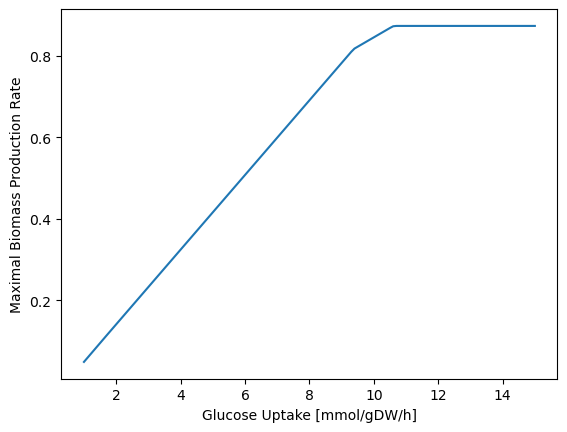

In [10]:
glucose_uptake_values = np.arange(1, 15.1, 0.1) 
glucose_lower_bound_values = -glucose_uptake_values
biomass_values = []

# find the FBA solution for each updated lower bound
for lower_bound_value in glucose_lower_bound_values:
    exglc.lower_bound = lower_bound_value
    fba_solution = model.optimize()
    biomass_values.append(fba_solution.objective_value)

plt.plot(glucose_uptake_values, biomass_values)
plt.xlabel("Glucose Uptake [mmol/gDW/h]")
plt.ylabel("Maximal Biomass Production Rate")
plt.show()



4b. Does the growth rate increase indefinitely with increasing glucose exchange reaction flux bound?
Please explain your observations. [15 pt]
Answer: No, growth is limited, we see that graph is divided into 3 parts, and in the end it has reached the plateau, so growth rate doesn't increase indefinitely because metabolism reached its maximum capacity of glucose intake

4c. The curve displays three segments. Identify which process gets active in the second segment, by
inspecting fluxes of the exchange reactions. It is sufficient to state the ID of the relevant reaction.
Code below shows that Ex_ac_e has increased. We chose started point in first segment and end point in third segment to see what reaction got activated. It shows that acetate exctraction due to maximum capacity of the glucose intake
Code exaplnation: first cell ( 12 ) shows what reactions are there and second ( 13 ) finds which reaction got activated 

In [12]:

exchange_reactions = [r.id for r in model.exchanges]
print(exchange_reactions)

['EX_ac_e', 'EX_acald_e', 'EX_akg_e', 'EX_co2_e', 'EX_etoh_e', 'EX_for_e', 'EX_fru_e', 'EX_fum_e', 'EX_glc__D_e', 'EX_gln__L_e', 'EX_glu__L_e', 'EX_h_e', 'EX_h2o_e', 'EX_lac__D_e', 'EX_mal__L_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e', 'EX_succ_e']


In [13]:
exglc.lower_bound = -1
sol_before = model.optimize()


exglc.lower_bound = -14
sol_after = model.optimize()


for rxn_id in exchange_reactions:
    before = sol_before.fluxes[rxn_id]
    after = sol_after.fluxes[rxn_id]
    if abs(before) < 1e-6 and abs(after) > 1e-6:
        print(f"{rxn_id}:  was  {before:.3f} became {after:.3f}")

EX_ac_e:  was  0.000 became 2.500


In [14]:
# this part is useless for assignment, just checking the versions for requirements.txt
import  matplotlib # i import matplotlib one more time because in the beginning was importe just pyplot
print("cobra:", cobra.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

cobra: 0.32.1
numpy: 2.1.3
matplotlib: 3.10.0
